<a href="https://colab.research.google.com/github/javageek2018/AirlineArrivalDelay/blob/%E2%80%9Cflight_data%E2%80%9D/EDA_Angela.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.3 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 5.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m6/8 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# ── Run this cell FIRST ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import time
import os
import requests
from io import StringIO

# For Jupyter notebooks — render plots inline
%matplotlib inline

print("✅ All imports successful!")

✅ All imports successful!


# Read in the data

In [ ]:
import pandas as pd

df = pd.read_parquet("data/flights_2018_2024_v2.parquet")

df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,Dest,CRSDepTime,DepTimeBlk,CRSArrTime,ArrDel15,CRSElapsedTime,Distance,DistanceGroup
0,2018,1,1,1,1,2018-01-01,WN,1491.0,ABQ,BWI,730,0700-0759,1310,0.0,220.0,1670.0,7
1,2018,1,1,1,1,2018-01-01,UA,2102.0,IAH,LAS,1420,1400-1459,1547,0.0,207.0,1222.0,5
2,2018,1,1,1,1,2018-01-01,UA,2101.0,IAH,SFO,2113,2100-2159,2340,0.0,267.0,1635.0,7
3,2018,1,1,1,1,2018-01-01,UA,2100.0,IAH,FLL,2010,2000-2059,2337,0.0,147.0,966.0,4
4,2018,1,1,1,1,2018-01-01,UA,2099.0,SAN,IAH,1340,1300-1359,1848,0.0,188.0,1303.0,6


In [ ]:
df.shape      # total rows and columns

(45968068, 17)

In [ ]:
df["Year"].unique()   # years present

array([2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [ ]:
summary = df.groupby("Year").size().to_frame("rows")
summary["columns"] = df.shape[1]

print(summary)

         rows  columns
Year                  
2018  7206195       17
2019  7422037       17
2020  4688354       17
2021  5995397       17
2022  6729125       17
2023  6847899       17
2024  7079061       17


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45968068 entries, 0 to 45968067
Data columns (total 17 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Year                             int64  
 1   Quarter                          int64  
 2   Month                            int64  
 3   DayofMonth                       int64  
 4   DayOfWeek                        int64  
 5   FlightDate                       object 
 6   Reporting_Airline                object 
 7   Flight_Number_Reporting_Airline  float64
 8   Origin                           object 
 9   Dest                             object 
 10  CRSDepTime                       int64  
 11  DepTimeBlk                       object 
 12  CRSArrTime                       int64  
 13  ArrDel15                         float64
 14  CRSElapsedTime                   float64
 15  Distance                         float64
 16  DistanceGroup                    int64  
dtypes: flo

## Convert columns to other data types

In [ ]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

cat_cols = ["Reporting_Airline", "Origin", "Dest", "DepTimeBlk"]
df[cat_cols] = df[cat_cols].astype("category")

df["Flight_Number_Reporting_Airline"] = df["Flight_Number_Reporting_Airline"].astype("string")

df["ArrDel15"] = df["ArrDel15"].astype("Int64")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45968068 entries, 0 to 45968067
Data columns (total 17 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   Year                             int64         
 1   Quarter                          int64         
 2   Month                            int64         
 3   DayofMonth                       int64         
 4   DayOfWeek                        int64         
 5   FlightDate                       datetime64[ns]
 6   Reporting_Airline                category      
 7   Flight_Number_Reporting_Airline  string        
 8   Origin                           category      
 9   Dest                             category      
 10  CRSDepTime                       int64         
 11  DepTimeBlk                       category      
 12  CRSArrTime                       int64         
 13  ArrDel15                         Int64         
 14  CRSElapsedTime                  

## Missingness Analysis

In [ ]:
import pandas as pd
import numpy as np

def missing_value_analysis(df: pd.DataFrame, show_all: bool = False) -> pd.DataFrame:
    # --- Basic counts ---
    total_rows = len(df)
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / total_rows) * 100
    present_count = df.notnull().sum()
    dtype_series = df.dtypes

    # --- Build summary table ---
    summary = pd.DataFrame({
        'dtype': dtype_series,
        'total_rows': total_rows,
        'missing_count': missing_count,
        'missing_pct': missing_pct.round(2),
        'present_count': present_count,
        'unique_values': df.nunique()
    }).sort_values('missing_pct', ascending=False)

    if not show_all:
        summary = summary[summary['missing_count'] > 0]

    # --- Print high-level overview ---
    total_cells = np.prod(df.shape)
    total_missing = df.isnull().sum().sum()
    cols_with_missing = (missing_count > 0).sum()

    print("=" * 55)
    print("       MISSING VALUE ANALYSIS REPORT")
    print("=" * 55)
    print(f"  📐 Shape              : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"  🔢 Total cells        : {total_cells:,}")
    print(f"  ❌ Total missing      : {total_missing:,} ({total_missing/total_cells*100:.2f}%)")
    print(f"  📋 Columns w/ missing : {cols_with_missing} / {df.shape[1]}")
    print(f"  ✅ Complete rows       : {df.dropna().shape[0]:,} / {df.shape[0]:,}")
    print("=" * 55)

    return summary

def missing_pattern_analysis(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """
    Identify co-occurrence patterns of missing values.

    Shows which combinations of columns tend to be missing together.
    """
    # Encode each row's missing pattern as a string signature
    pattern = df.isnull().astype(int)
    cols = df.columns.tolist()

    pattern['_signature'] = pattern.apply(
        lambda row: ' | '.join([c for c, v in zip(cols, row) if v == 1]) or '✅ No missing',
        axis=1
    )

    pattern_counts = (
        pattern['_signature']
        .value_counts()
        .head(top_n)
        .reset_index()
    )
    pattern_counts.columns = ['missing_columns_pattern', 'row_count']
    pattern_counts['pct_of_rows'] = (pattern_counts['row_count'] / len(df) * 100).round(2)

    print(f"\n🔍 Top {top_n} Missing Value Patterns:\n")
    return pattern_counts

In [ ]:
# Run the main analysis
summary = missing_value_analysis(df, show_all=True)
print(summary)

# View co-occurrence patterns
patterns = missing_pattern_analysis(df)
print(patterns)

       MISSING VALUE ANALYSIS REPORT
  📐 Shape              : 45968068 rows × 17 columns
  🔢 Total cells        : 781,457,156
  ❌ Total missing      : 1,110,074 (0.14%)
  📋 Columns w/ missing : 3 / 17
  ✅ Complete rows       : 44,858,151 / 45,968,068
                                          dtype  total_rows  missing_count  \
ArrDel15                                  Int64    45968068        1109916   
Year                                      int64    45968068              0   
Dest                                   category    45968068              0   
Distance                                float64    45968068              0   
CRSElapsedTime                          float64    45968068            157   
CRSArrTime                                int64    45968068              0   
DepTimeBlk                             category    45968068              0   
CRSDepTime                                int64    45968068              0   
Origin                                 category

## Distribution of ArrDelay15

In [ ]:
# Summary statistics
print("\n📊 ArrDel15 Summary Statistics")
print(df["ArrDel15"].describe().round(2))


📊 ArrDel15 Summary Statistics
count    44858152.0
mean           0.19
std            0.39
min             0.0
25%             0.0
50%             0.0
75%             0.0
max             1.0
Name: ArrDel15, dtype: Float64


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Arrival Delay Summary Statistics by Year
# ══════════════════════════════════════════════════════════════════════

yearly_stats = (
    df.groupby("Year")["ArrDel15"]
      .agg(
          Count    = "count",
          Mean     = "mean"
      )
      .round(2)
)

# ── Pretty Print ──────────────────────────────────────────────────────
print("=" * 90)
print("✈️  ARRIVAL DELAY SUMMARY STATISTICS BY YEAR")
print("=" * 90)
print(yearly_stats.to_string())
print("-" * 90)

# ── Overall across all years ──────────────────────────────────────────
print("\n📌 OVERALL (All Years Combined)")
print(f"   Count       : {df['ArrDel15'].count():,}")
print(f"   Mean        : {df['ArrDel15'].mean():.2f}")

✈️  ARRIVAL DELAY SUMMARY STATISTICS BY YEAR
        Count  Mean
Year               
2018  7071464  0.19
2019  7268232  0.19
2020  4399575   0.1
2021  5878219  0.17
2022  6532012  0.21
2023  6743403  0.21
2024  6965247  0.21
------------------------------------------------------------------------------------------

📌 OVERALL (All Years Combined)
   Count       : 44,858,152
   Mean        : 0.19


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Class Imbalance Ratio by Year
# ══════════════════════════════════════════════════════════════════════

imbalance = (
    df.groupby("Year")["ArrDel15"]
      .agg(
          Total_Flights = "count",
          Delayed       = "sum",                              # class 1
      )
      .assign(
          On_Time         = lambda x: x["Total_Flights"] - x["Delayed"],   # class 0
          Delayed_Pct     = lambda x: (x["Delayed"] / x["Total_Flights"] * 100).round(2),
          On_Time_Pct     = lambda x: (x["On_Time"] / x["Total_Flights"] * 100).round(2),
          Imbalance_Ratio = lambda x: (x["On_Time"] / x["Delayed"]).round(2)  # majority / minority
      )
)

# ── Pretty Print ──────────────────────────────────────────────────────
print("=" * 95)
print("✈️  CLASS IMBALANCE RATIO BY YEAR  (On-Time vs Delayed ≥15 min)")
print("=" * 95)
print(imbalance.to_string())
print("-" * 95)

# ── Overall ───────────────────────────────────────────────────────────
total    = len(df)
delayed  = df["ArrDel15"].sum()
on_time  = total - delayed
ratio    = round(on_time / delayed, 2)

print(f"\n📌 OVERALL")
print(f"   Total Flights    : {total:,}")
print(f"   On-Time (class 0): {on_time:,}  ({on_time/total*100:.2f}%)")
print(f"   Delayed (class 1): {delayed:,}  ({delayed/total*100:.2f}%)")
print(f"   Imbalance Ratio  : {ratio} : 1")

✈️  CLASS IMBALANCE RATIO BY YEAR  (On-Time vs Delayed ≥15 min)
      Total_Flights  Delayed  On_Time  Delayed_Pct  On_Time_Pct  Imbalance_Ratio
Year                                                                            
2018        7071464  1352165  5719299        19.12        80.88             4.23
2019        7268232  1389253  5878979        19.11        80.89             4.23
2020        4399575   431921  3967654         9.82        90.18             9.19
2021        5878219  1010332  4867887        17.19        82.81             4.82
2022        6532012  1376798  5155214        21.08        78.92             3.74
2023        6743403  1386699  5356704        20.56        79.44             3.86
2024        6965247  1449966  5515281        20.82        79.18              3.8
-----------------------------------------------------------------------------------------------

📌 OVERALL
   Total Flights    : 45,968,068
   On-Time (class 0): 37,570,934  (81.73%)
   Delayed (class 1): 8,

Delayed flights constitute ~18/.27% of the data, with imbalance increasing during COVID. Several post‑arrival fields are excluded to prevent leakage.

   Year  Pct_Delayed
0  2018        19.12
1  2019        19.11
2  2020         9.82
3  2021        17.19
4  2022        21.08
5  2023        20.56
6  2024        20.82


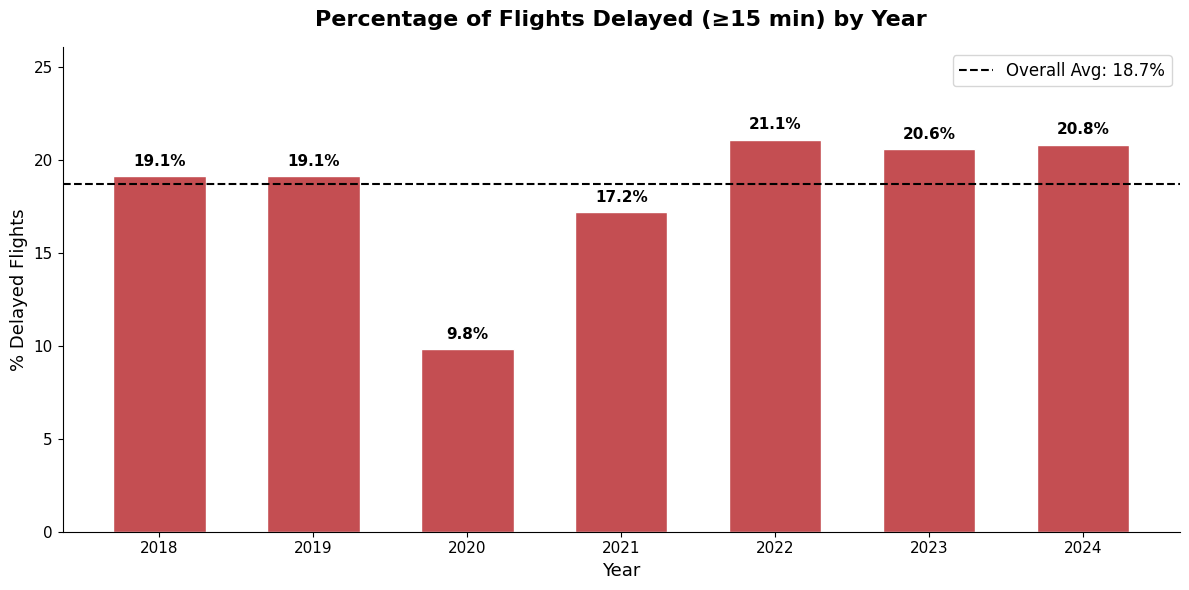

In [ ]:
# ── Calculate % Delayed by Year ──────────────────────────────────────
delay_pct = (
    df.groupby("Year")["ArrDel15"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
      .rename(columns={"ArrDel15": "Pct_Delayed"})
)

print(delay_pct)

# ══════════════════════════════════════════════════════════════════════
# Bar Chart
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    delay_pct["Year"].astype(str),
    delay_pct["Pct_Delayed"],
    color="#c44e52",
    edgecolor="white",
    width=0.6
)

# ── Add value labels on top of each bar ──────────────────────────────
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.4,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ── Add a horizontal reference line at the overall average ───────────
overall_avg = df["ArrDel15"].mean() * 100
ax.axhline(
    y=overall_avg,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall Avg: {overall_avg:.1f}%"
)

# ── Formatting ───────────────────────────────────────────────────────
ax.set_title("Percentage of Flights Delayed (≥15 min) by Year",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("% Delayed Flights", fontsize=13)
ax.set_ylim(0, delay_pct["Pct_Delayed"].max() + 5)
ax.legend(fontsize=12, loc="upper right")
ax.tick_params(axis="both", labelsize=11)

# Remove top & right spines for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("delay_pct_by_year.png", dpi=150, bbox_inches="tight")
plt.show()


# Bring in weather data

In [ ]:
# Get all unique airport codes (both origin and destination)
airports = sorted(set(df['Origin'].unique()) | set(df['Dest'].unique()))
print(f"Total unique airports: {len(airports)}")
print(airports[:10])  # Preview

Total unique airports: 384
['ABE', 'ABI', 'ABQ', 'ABR', 'ABY', 'ACK', 'ACT', 'ACV', 'ACY', 'ADK']


In [ ]:
# Copy of bts data from df into bts
bts = df

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================
YEARS        = list(range(2018, 2025))     # 2018, 2019, ... 2024
TIMEZONE     = 'America/New_York'
SAVE_DIR     = 'weather_cache'
DELAY        = 5
OUTPUT_FILE  = 'bts_with_weather.parquet'

total_jobs = len(airports) * len(YEARS)
print(f"📋 BTS records:     {len(bts):,}")
print(f"✈️  Unique airports: {len(airports)}")
print(f"📅 Years:           {YEARS[0]}–{YEARS[-1]} ({len(YEARS)} years)")
print(f"📦 Total downloads: {len(airports)} airports × {len(YEARS)} years = {total_jobs}")
print(f"⏱️  Estimated time:  ~{(total_jobs * DELAY) // 60} minutes (first run)")
print()

📋 BTS records:     45,968,068
✈️  Unique airports: 384
📅 Years:           2018–2024 (7 years)
📦 Total downloads: 384 airports × 7 years = 2688
⏱️  Estimated time:  ~224 minutes (first run)



In [ ]:
# ============================================================
# STEP 1: Download function with retry logic
# ============================================================
def fetch_weather(station, year, max_retries=3):
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?"
        f"station={station}&"
        "data=tmpf&data=dwpf&data=relh&data=sknt&data=gust&"
        "data=vsby&data=p01i&data=wxcodes&data=feel&"
        f"tz={TIMEZONE}&"
        "format=onlycomma&latlon=no&missing=empty&"
        "trace=0.0001&"
        f"year1={year}&month1=1&day1=1&"
        f"year2={year}&month2=12&day2=31"
    )

    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=60)

            if response.status_code == 429:
                wait_time = (attempt + 1) * 30
                print(f"    ⏳ 429 Rate limited. Waiting {wait_time}s "
                      f"(attempt {attempt + 1}/{max_retries})...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()

            df = pd.read_csv(StringIO(response.text))
            if len(df) > 0:
                return df
            return None

        except requests.exceptions.RequestException as e:
            wait_time = (attempt + 1) * 15
            print(f"    ⚠️ Error: {e}. Retrying in {wait_time}s...")
            time.sleep(wait_time)

    return None

In [ ]:
# ============================================================
# STEP 2: Download weather — one file per airport per year
# ============================================================
print("=" * 60)
print("DOWNLOADING WEATHER DATA")
print("=" * 60)

os.makedirs(SAVE_DIR, exist_ok=True)

all_weather = []
failed_jobs = []
job_num = 0

for year in YEARS:
    print(f"\n--- {year} ---")

    for i, airport in enumerate(airports, 1):
        job_num += 1
        cache_file = os.path.join(SAVE_DIR, f"{airport}_{year}.csv")

        # Load from cache if already downloaded
        if os.path.exists(cache_file):
            df = pd.read_csv(cache_file)
            all_weather.append(df)
            print(f"  [{job_num}/{total_jobs}] 📁 {airport} {year}: "
                  f"Cache ({len(df):,} records)")
            continue

        # Download fresh
        print(f"  [{job_num}/{total_jobs}] ⬇️  {airport} {year}...", end=" ")
        df = fetch_weather(airport, year, max_retries=3)

        if df is not None:
            df.to_csv(cache_file, index=False)
            all_weather.append(df)
            print(f"✅ {len(df):,} records")
        else:
            failed_jobs.append((airport, year))
            print("❌ No data")

        time.sleep(DELAY)

print(f"\n  ✅ Downloaded: {total_jobs - len(failed_jobs)}/{total_jobs}")
print()

DOWNLOADING WEATHER DATA

--- 2018 ---
  [1/2688] ⬇️  ABE 2018... ✅ 114,637 records
  [2/2688] ⬇️  ABI 2018... ✅ 113,695 records
  [3/2688] ⬇️  ABQ 2018... ✅ 112,889 records
  [4/2688] ⬇️  ABR 2018... ✅ 112,091 records
  [5/2688] ⬇️  ABY 2018... ✅ 112,809 records
  [6/2688] ⬇️  ACK 2018... ✅ 113,289 records
  [7/2688] ⬇️  ACT 2018... ✅ 114,773 records
  [8/2688] ⬇️  ACV 2018... ✅ 116,620 records
  [9/2688] ⬇️  ACY 2018... ✅ 115,291 records
  [10/2688] ⬇️  ADK 2018... ❌ No data
  [11/2688] ⬇️  ADQ 2018... ❌ No data
  [12/2688] ⬇️  AEX 2018... ✅ 113,762 records
  [13/2688] ⬇️  AGS 2018... ✅ 114,756 records
  [14/2688] ⬇️  AKN 2018... ❌ No data
  [15/2688] ⬇️  ALB 2018... ✅ 99,582 records
  [16/2688] ⬇️  ALO 2018... ✅ 114,552 records
  [17/2688] ⬇️  ALS 2018... ✅ 112,858 records
  [18/2688] ⬇️  ALW 2018... ✅ 108,883 records
  [19/2688] ⬇️  AMA 2018... ✅ 113,678 records
  [20/2688] ⬇️  ANC 2018... ❌ No data
  [21/2688] ⬇️  APN 2018... ✅ 112,351 records
  [22/2688] ⬇️  ART 2018... ✅ 100,234

In [ ]:
# ============================================================
# STEP 3: Retry failed stations with ICAO prefix
# ============================================================
if failed_jobs:
    print("=" * 60)
    print(f"RETRYING {len(failed_jobs)} FAILED DOWNLOADS")
    print("=" * 60)

    still_failed = []

    for airport, year in failed_jobs:
        cache_file = os.path.join(SAVE_DIR, f"{airport}_{year}.csv")
        print(f"  🔄 Retrying {airport} {year} as K{airport}...", end=" ")
        time.sleep(10)

        df = fetch_weather(f"K{airport}", year, max_retries=3)

        if df is not None:
            df['station'] = airport
            df.to_csv(cache_file, index=False)
            all_weather.append(df)
            print(f"✅ Recovered ({len(df):,} records)")
        else:
            still_failed.append((airport, year))
            print("❌ Permanently failed")

    if still_failed:
        failed_airports = sorted(set(a for a, y in still_failed))
        print(f"\n  ⛔ No data available for: {failed_airports}")
        print(f"     Total failed airport-year combos: {len(still_failed)}")
    print()
else:
    still_failed = []
    print("No failed downloads — skipping retry step 🎉\n")

RETRYING 295 FAILED DOWNLOADS
  🔄 Retrying ADK 2018 as KADK... ❌ Permanently failed
  🔄 Retrying ADQ 2018 as KADQ... ❌ Permanently failed
  🔄 Retrying AKN 2018 as KAKN... ❌ Permanently failed
  🔄 Retrying ANC 2018 as KANC... ❌ Permanently failed
  🔄 Retrying AZA 2018 as KAZA... ❌ Permanently failed
  🔄 Retrying BET 2018 as KBET... ❌ Permanently failed
  🔄 Retrying BKG 2018 as KBKG... ❌ Permanently failed
  🔄 Retrying BQN 2018 as KBQN... ❌ Permanently failed
  🔄 Retrying BRW 2018 as KBRW... ❌ Permanently failed
  🔄 Retrying CDB 2018 as KCDB... ❌ Permanently failed
  🔄 Retrying CDV 2018 as KCDV... ❌ Permanently failed
  🔄 Retrying DLG 2018 as KDLG... ❌ Permanently failed
  🔄 Retrying FAI 2018 as KFAI... ❌ Permanently failed
  🔄 Retrying FCA 2018 as KFCA... ❌ Permanently failed
  🔄 Retrying GST 2018 as KGST... ❌ Permanently failed
  🔄 Retrying GUM 2018 as KGUM... ❌ Permanently failed
  🔄 Retrying HHH 2018 as KHHH... ❌ Permanently failed
  🔄 Retrying HNL 2018 as KHNL... ❌ Permanently faile

In [ ]:
# ============================================================
# STEP 4: Combine and clean weather data
# ============================================================
print("=" * 60)
print("CLEANING WEATHER DATA")
print("=" * 60)

weather_all = pd.concat(all_weather, ignore_index=True)
print(f"  Raw records: {len(weather_all):,}")

weather_all['valid'] = pd.to_datetime(weather_all['valid'])
weather_all['date']  = weather_all['valid'].dt.date.astype(str)
weather_all['hour']  = weather_all['valid'].dt.hour

numeric_cols = ['tmpf', 'dwpf', 'relh', 'sknt', 'gust', 'vsby', 'p01i', 'feel']
for col in numeric_cols:
    if col in weather_all.columns:
        weather_all[col] = pd.to_numeric(weather_all[col], errors='coerce')

weather_hourly = weather_all.groupby(['station', 'date', 'hour']).agg(
    temp_f       = ('tmpf', 'mean'),
    dewpoint_f   = ('dwpf', 'mean'),
    humidity     = ('relh', 'mean'),
    feels_like_f = ('feel', 'mean'),
    wind_kts     = ('sknt', 'mean'),
    gust_kts     = ('gust', 'max'),
    visibility   = ('vsby', 'mean'),
    precip_in    = ('p01i', 'sum'),
    wx_codes     = ('wxcodes', lambda x: '|'.join(x.dropna().unique())),
).reset_index()

print(f"  Hourly records: {len(weather_hourly):,}")
print(f"  Stations: {weather_hourly['station'].nunique()}")
print(f"  Date range: {weather_hourly['date'].min()} → {weather_hourly['date'].max()}")
print()


CLEANING WEATHER DATA
  Raw records: 247,464,145
  Hourly records: 20,842,501
  Stations: 343
  Date range: 2018-01-01 → 2024-12-30



In [ ]:
# ============================================================
# STEP 5: Engineer weather features
# ============================================================
print("=" * 60)
print("ENGINEERING WEATHER FEATURES")
print("=" * 60)

weather_hourly['is_rain'] = weather_hourly['wx_codes'].str.contains(
    'RA|DZ|TS', case=False, na=False).astype(int)

weather_hourly['is_snow'] = weather_hourly['wx_codes'].str.contains(
    'SN|SG|PL|IC', case=False, na=False).astype(int)

weather_hourly['is_fog'] = weather_hourly['wx_codes'].str.contains(
    'FG|BR|HZ', case=False, na=False).astype(int)

weather_hourly['low_visibility'] = (
    weather_hourly['visibility'] < 3).astype(int)

weather_hourly['high_wind'] = (
    weather_hourly['gust_kts'] > 25).astype(int)

weather_hourly['severe_weather'] = (
    weather_hourly['is_rain']        |
    weather_hourly['is_snow']        |
    weather_hourly['low_visibility'] |
    weather_hourly['high_wind']
).astype(int)

weather_hourly.to_parquet('weather_hourly_all_airports.parquet', index=False)

print("  ✅ Features: is_rain, is_snow, is_fog, "
      "low_visibility, high_wind, severe_weather")
print("  💾 Saved: weather_hourly_all_airports.parquet")
print()


ENGINEERING WEATHER FEATURES
  ✅ Features: is_rain, is_snow, is_fog, low_visibility, high_wind, severe_weather
  💾 Saved: weather_hourly_all_airports.parquet



In [ ]:
bts.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'Flight_Number_Reporting_Airline', 'Origin',
       'Dest', 'CRSDepTime', 'DepTimeBlk', 'CRSArrTime', 'ArrDel15',
       'CRSElapsedTime', 'Distance', 'DistanceGroup'],
      dtype='object')

In [ ]:
# ============================================================
# LOAD SAVED WEATHER DATA
# ============================================================
print("Loading saved weather data...")

weather_hourly = pd.read_parquet('weather_hourly_all_airports.parquet')

print(f"  ✅ Loaded: {len(weather_hourly):,} hourly records")
print(f"  Stations: {weather_hourly['station'].nunique()}")
print(f"  Date range: {weather_hourly['date'].min()} → {weather_hourly['date'].max()}")
print(f"  Columns: {list(weather_hourly.columns)}")
print()

OUTPUT_FILE = 'bts_with_weather.parquet'

Loading saved weather data...
  ✅ Loaded: 20,842,501 hourly records
  Stations: 343
  Date range: 2018-01-01 → 2024-12-30
  Columns: ['station', 'date', 'hour', 'temp_f', 'dewpoint_f', 'humidity', 'feels_like_f', 'wind_kts', 'gust_kts', 'visibility', 'precip_in', 'wx_codes', 'is_rain', 'is_snow', 'is_fog', 'low_visibility', 'high_wind', 'severe_weather']



In [ ]:
# ============================================================
# STEP 6: Prepare BTS join keys
# ============================================================
print("=" * 60)
print("STEP 6: PREPARING BTS MERGE KEYS")
print("=" * 60)

bts['FlightDate']  = pd.to_datetime(bts['FlightDate'])
bts['date']        = bts['FlightDate'].dt.date.astype(str)
bts['dep_hour']    = (bts['CRSDepTime'] // 100).astype('Int64')
bts['arr_hour']    = (bts['CRSArrTime'] // 100).astype('Int64')

# ── New columns: scheduled times minus 2 hours (clamped to 0–23) ──
bts['dep_hour_minus2'] = ((bts['dep_hour'] - 2) % 24).astype('Int64')
bts['arr_hour_minus2'] = ((bts['arr_hour'] - 2) % 24).astype('Int64')

print(f"  BTS records:  {len(bts):,}")
print(f"  Date range:   {bts['FlightDate'].min()} → {bts['FlightDate'].max()}")
print(f"  dep_hour sample (orig → -2h): "
      f"{bts['dep_hour'].iloc[0]} → {bts['dep_hour_minus2'].iloc[0]}")
print(f"  arr_hour sample (orig → -2h): "
      f"{bts['arr_hour'].iloc[0]} → {bts['arr_hour_minus2'].iloc[0]}")
print()

STEP 6: PREPARING BTS MERGE KEYS
  BTS records:  45,968,068
  Date range:   2018-01-01 00:00:00 → 2024-12-31 00:00:00
  dep_hour sample (orig → -2h): 7 → 5
  arr_hour sample (orig → -2h): 13 → 11



In [ ]:
# ============================================================
# STEP 7: Merge ORIGIN weather
# ============================================================
print("=" * 60)
print("STEP 7: MERGING ORIGIN WEATHER")
print("=" * 60)

origin_wx = weather_hourly.copy()
origin_wx.columns = ['station', 'date', 'hour'] + \
    [f'origin_{c}' for c in origin_wx.columns[3:]]

bts_merged = bts.merge(
    origin_wx,
    left_on  = ['Origin', 'date', 'dep_hour_minus2'],
    right_on = ['station', 'date', 'hour'],
    how      = 'left'
).drop(columns=['station', 'hour'])

print(f"  Match rate: {bts_merged['origin_temp_f'].notna().mean():.1%}")
print()

STEP 7: MERGING ORIGIN WEATHER
  Match rate: 96.5%



In [ ]:
# ============================================================
# STEP 8: Merge DESTINATION weather
# ============================================================
print("=" * 60)
print("STEP 8: MERGING DESTINATION WEATHER")
print("=" * 60)

dest_wx = weather_hourly.copy()
dest_wx.columns = ['station', 'date', 'hour'] + \
    [f'dest_{c}' for c in dest_wx.columns[3:]]

bts_merged = bts_merged.merge(
    dest_wx,
    left_on  = ['Dest', 'date', 'arr_hour_minus2'],
    right_on = ['station', 'date', 'hour'],
    how      = 'left'
).drop(columns=['station', 'hour'])

print(f"  Match rate: {bts_merged['dest_temp_f'].notna().mean():.1%}")
print()

STEP 8: MERGING DESTINATION WEATHER
  Match rate: 96.6%



In [ ]:
# ============================================================
# STEP 9: Validate and save
# ============================================================
print("=" * 60)
print("STEP 9: VALIDATION & OUTPUT")
print("=" * 60)

print(f"\n  📐 Final shape: {bts_merged.shape}")

print(f"\n  🌤️  Origin match rate:  "
      f"{bts_merged['origin_temp_f'].notna().mean():.1%}")
print(f"  🌤️  Dest match rate:    "
      f"{bts_merged['dest_temp_f'].notna().mean():.1%}")

weather_cols = [c for c in bts_merged.columns
                if c.startswith('origin_') or c.startswith('dest_')]
print(f"\n  🆕 Weather columns added: {len(weather_cols)}")

if 'WEATHER_DELAY' in bts_merged.columns:
    wx_delay = bts_merged[bts_merged['WEATHER_DELAY'] > 0]
    if len(wx_delay) > 0:
        severe_delayed = wx_delay['origin_severe_weather'].mean()
        severe_overall = bts_merged['origin_severe_weather'].mean()
        print(f"\n  🔍 Sanity check:")
        print(f"      Severe weather rate (delayed flights): {severe_delayed:.2f}")
        print(f"      Severe weather rate (all flights):     {severe_overall:.2f}")
        if severe_delayed > severe_overall:
            print("      ✅ Looks correct!")

bts_merged.to_parquet(OUTPUT_FILE, index=False)

print(f"\n  💾 Saved: {OUTPUT_FILE}")
print(f"     Size: {os.path.getsize(OUTPUT_FILE) / (1024**2):.1f} MB")

print("\n" + "=" * 60)
print("✅ PIPELINE COMPLETE")
print("=" * 60)

STEP 9: VALIDATION & OUTPUT

  📐 Final shape: (45968068, 52)

  🌤️  Origin match rate:  96.5%
  🌤️  Dest match rate:    96.6%

  🆕 Weather columns added: 30

  💾 Saved: bts_with_weather.parquet
     Size: 1497.5 MB

✅ PIPELINE COMPLETE


In [ ]:
# Option 1: Temporary context manager (recommended ✅)
with pd.option_context('display.max_columns', None,
                        'display.max_rows', None,
                        'display.width', None):
    display(bts_merged.head(5))

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,Dest,CRSDepTime,DepTimeBlk,CRSArrTime,ArrDel15,CRSElapsedTime,Distance,DistanceGroup,date,dep_hour,arr_hour,dep_hour_minus2,arr_hour_minus2,origin_temp_f,origin_dewpoint_f,origin_humidity,origin_feels_like_f,origin_wind_kts,origin_gust_kts,origin_visibility,origin_precip_in,origin_wx_codes,origin_is_rain,origin_is_snow,origin_is_fog,origin_low_visibility,origin_high_wind,origin_severe_weather,dest_temp_f,dest_dewpoint_f,dest_humidity,dest_feels_like_f,dest_wind_kts,dest_gust_kts,dest_visibility,dest_precip_in,dest_wx_codes,dest_is_rain,dest_is_snow,dest_is_fog,dest_low_visibility,dest_high_wind,dest_severe_weather
0,2018,1,1,1,1,2018-01-01,WN,1491.0,ABQ,BWI,730,0700-0759,1310,0,220.0,1670.0,7,2018-01-01,7,13,5,11,21.0,8.1,56.88,9.17,8.818182,NaN,10.000000,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,21.9,3.0,43.38,9.70,9.692308,16.0,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
1,2018,1,1,1,1,2018-01-01,UA,2102.0,IAH,LAS,1420,1400-1459,1547,0,207.0,1222.0,5,2018-01-01,14,15,12,13,37.0,15.1,40.34,26.94,14.500000,21.0,10.000000,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,57.0,14.0,18.08,57.00,0.461538,NaN,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
2,2018,1,1,1,1,2018-01-01,UA,2101.0,IAH,SFO,2113,2100-2159,2340,0,267.0,1635.0,7,2018-01-01,21,23,19,21,34.0,12.9,41.26,24.99,10.666667,NaN,10.000000,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,57.0,47.0,68.90,57.00,0.230769,NaN,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,1,1,1,1,2018-01-01,UA,2100.0,IAH,FLL,2010,2000-2059,2337,0,147.0,966.0,4,2018-01-01,20,23,18,21,36.0,12.0,36.62,29.65,8.692308,NaN,10.000000,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,64.0,61.0,89.97,64.00,8.000000,NaN,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
4,2018,1,1,1,1,2018-01-01,UA,2099.0,SAN,IAH,1340,1300-1359,1848,0,188.0,1303.0,6,2018-01-01,13,18,11,16,52.5,52.5,100.00,52.55,1.357143,NaN,0.149286,0.0,FG,0.0,0.0,1.0,1.0,0.0,1.0,40.0,10.9,29.92,31.69,11.571429,NaN,10.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0
